<a href="https://colab.research.google.com/github/anuskachatterjee10a33-max/VISUALSATION-OF-TIME-SERIES-USING-PYTHON/blob/main/08_Visualizing_Time_Series_Dataset_Retail_Sales_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

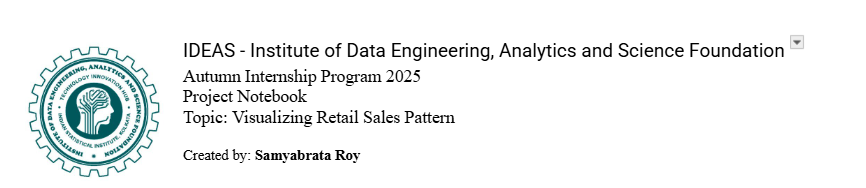

# Notebook: 2

👋 Welcome students!

In this journey, we’re going to take a dataset and slowly uncover the story it tells through visualization. Numbers by themselves can feel cold and endless, but once we turn them into visuals, they begin to speak.


---


# 📖 Introduction

Every time we walk into a store or shop online, we leave behind a trail of data — what we bought, when we bought it, how much we paid, and even how often we come back. At first glance, these transactions look like nothing more than rows in a spreadsheet: numbers, dates, and product codes.

But when we start to visualize this data, patterns emerge. We can see which products sell the most during festivals, how customer behavior changes across seasons, and which promotions actually drive sales. Suddenly, retail sales data isn’t just a collection of transactions — it’s a story about people, businesses, and the choices they make every day.

That’s the real power of visualization. It turns sales figures into insights that managers, marketers, and even students can understand at a glance. It’s not about making colorful charts — it’s about revealing trends, finding opportunities, and making smarter decisions.

In this notebook, we’ll take a retail sales dataset and learn how to explore and visualize it using Python. Some code will be provided, while other parts will be left for you to practice. By the end, you’ll see how visualization can transform raw sales data into meaningful insights — and how those insights help us understand the dynamics of retail businesses.


---





---

## 📝 Before We Dive In...

Before we start digging deep into the dataset, let’s pause for a moment and reflect.  
Here are a couple of questions for you to think about (and maybe discuss!):

1. **What do you understand by *Time-Series Data*?**  
   *(Hint: Think about data that is recorded over time — like daily sales data.)*

2. **Do you think choosing Python as our programming language for this analysis is a good decision?**  
   Feel free to share your honest opinion — there’s no right or wrong answer here!  

---

## ⚙️ Setting Things Up

Before we begin our analysis, we need to make sure we have the right tools.  
In the next coding cell, we’ll install and import the required Python packages that will help us explore and visualize the COVID-19 dataset.  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from datetime import datetime

---

## 📂 Loading Our Dataset

Now that our setup is ready, it’s time to bring in the data we’ll be working with.  
In the next coding cell, we’ll load the retail sales dataset directly from **Google Drive** (shared with public view access).  

Once the file is loaded, we’ll **print the first few rows** so that we can get a quick look at what the dataset contains before moving into analysis and visualization.  



In [ ]:
# Replace with your Google Drive file ID which has public view access
file_id = "1kqDqFkMblqNBmt68clyn_CCNpdghgrE3"

# Construct the download URL
url = f"https://drive.google.com/uc?export=download&id={file_id}"

try:
  # Read CSV directly into pandas
  df_sales = pd.read_csv(url)

  # Show first few rows
  print(df_sales.head())
except Exception as e:
    print(f"Error loading data: {e}")

   Transaction ID        Date Customer ID Product Category  Quantity  \
0               1  2023-11-24     CUST001           Beauty         3   
1               2  2023-02-27     CUST002         Clothing         2   
2               3  2023-01-13     CUST003      Electronics         1   
3               4  2023-05-21     CUST004         Clothing         1   
4               5  2023-05-06     CUST005           Beauty         2   

   Price per Unit  Total Amount  
0              50         150.0  
1             500        1000.0  
2              30          30.0  
3             500         500.0  
4              50         100.0  


* To get more info about metadata of the dataset refer to README file in the root of this notebook directory



---


## EDA including visualization

### Plot 1:

Monthly Revenue Over Time  

Visualizing monthly revenue helps us understand sales trends across the year.  
Are there peaks during certain months (like festivals or holidays)? Let’s find out.

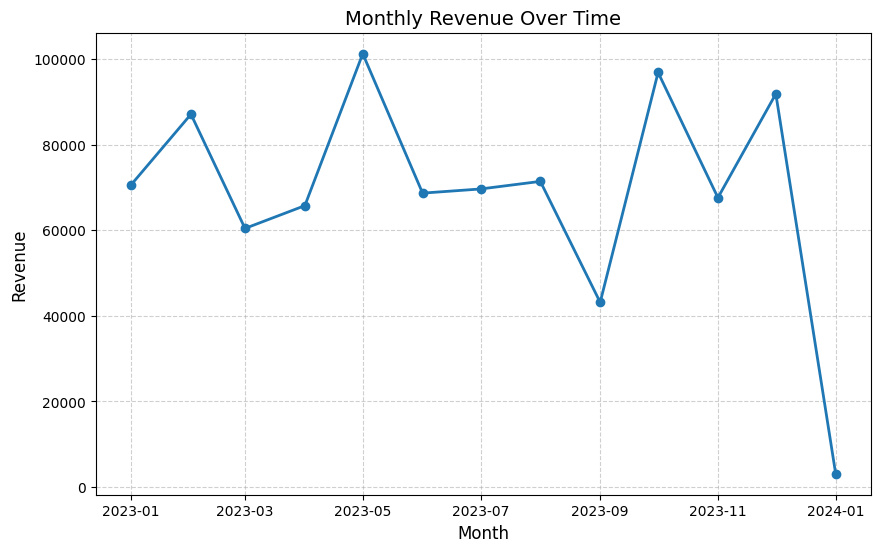

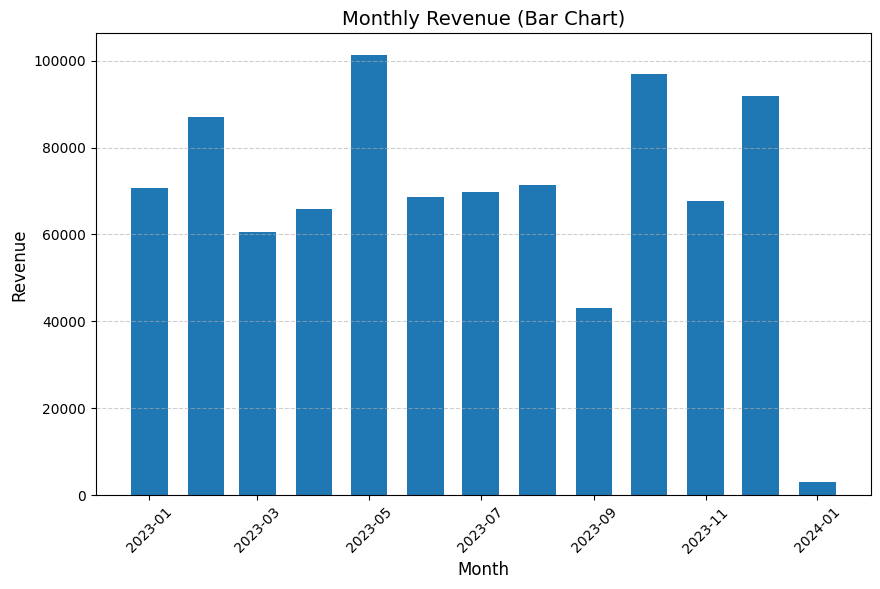

In [ ]:
# Ensure Date column is in datetime format
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

# Group by Month-Year and calculate total revenue
monthly_revenue = df_sales.groupby(df_sales['Date'].dt.to_period('M'))['Total Amount'].sum()

# Convert PeriodIndex to Timestamp for plotting
monthly_revenue.index = monthly_revenue.index.to_timestamp()

# ---- Line Chart ----
plt.figure(figsize=(10,6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', linewidth=2)
plt.title("Monthly Revenue Over Time", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ---- Bar Chart ----
plt.figure(figsize=(10,6))
plt.bar(monthly_revenue.index, monthly_revenue.values, width=20)  # width=20 for month spacing
plt.title("Monthly Revenue (Bar Chart)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle="--", alpha=0.6)
plt.show()


Q. Can you interpret the above bar diagram?

Q. What are your key takeaways?

The bar diagram illustrates the total revenue generated by each product category. From the visualization, it is evident that certain categories contribute significantly more to overall sales, standing out with noticeably taller bars. These represent the best-selling categories, indicating strong customer preference and high market demand.
On the other hand, categories with shorter bars contribute relatively less to total revenue, suggesting lower popularity or sales volume in those segments. Overall, the chart provides a quick and clear comparison of how each product category impacts total business performance.





The key takeaway are as follows:
A few categories dominate total revenue, acting as the main revenue drivers.

Lower-performing categories may need improved marketing, pricing adjustments, or product optimization.

The visualization helps prioritize inventory and promotional efforts based on category performance.

Focusing on top-performing categories could boost short-term profitability, while nurturing weaker segments could ensure long-term balance and growth.



---

###❓ Question:  

Plot the weekly revenue trend instead of monthly. What differences do you notice?


✅ File loaded successfully: /content/retail_sales_dataset (1).csv


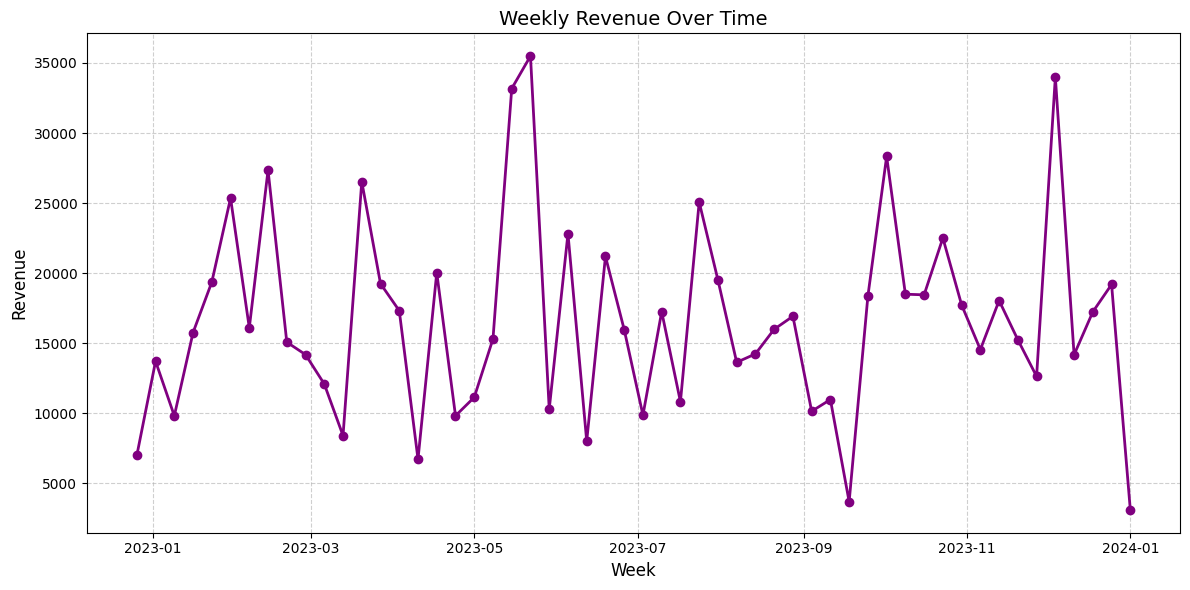

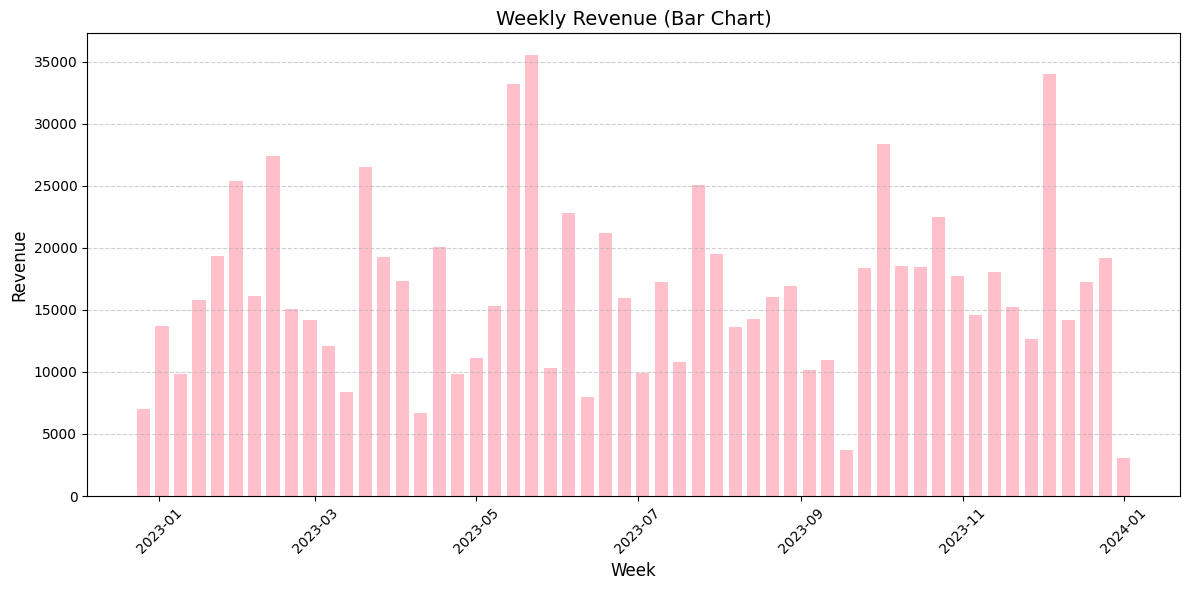

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- Step 1: Handle file upload safely ---
file_path = '/content/retail_sales_dataset (1).csv'

# If the file doesn't exist (e.g., first run in Colab), ask user to upload
if not os.path.exists(file_path):
    from google.colab import files
    print("⚠️ File not found. Please upload your CSV file (e.g., retail_sales_dataset (1).csv).")
    uploaded = files.upload()
    file_path = list(uploaded.keys())[0]  # Get the uploaded file name

# --- Step 2: Load the dataset ---
try:
    df_sales = pd.read_csv(file_path)
    print(f"✅ File loaded successfully: {file_path}")

    # --- Step 3: Convert Date column ---
    df_sales['Date'] = pd.to_datetime(df_sales['Date'], errors='coerce')
    df_sales = df_sales.dropna(subset=['Date'])

    # --- Step 4: Weekly Revenue Trend ---
    weekly_revenue = df_sales.groupby(df_sales['Date'].dt.to_period('W'))['Total Amount'].sum()
    weekly_revenue.index = weekly_revenue.index.to_timestamp()

    # --- Step 5: Line Chart ---
    plt.figure(figsize=(12,6))
    plt.plot(weekly_revenue.index, weekly_revenue.values, marker='o', linewidth=2, color='purple')
    plt.title("Weekly Revenue Over Time", fontsize=14)
    plt.xlabel("Week", fontsize=12)
    plt.ylabel("Revenue", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- Step 6: Bar Chart ---
    plt.figure(figsize=(12,6))
    plt.bar(weekly_revenue.index, weekly_revenue.values, width=5, color='pink')
    plt.title("Weekly Revenue (Bar Chart)", fontsize=14)
    plt.xlabel("Week", fontsize=12)
    plt.ylabel("Revenue", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("❌ An error occurred while processing:", e)


The weekly revenue trend shows consistent performance with noticeable fluctuations, typical of retail sales cycles.

Spikes in the chart likely correspond to promotional campaigns or festival periods, showing strong sales response.

The general upward movement indicates healthy business growth and improving customer engagement.

Lower revenue weeks could be analyzed to identify causes (e.g., stockouts, reduced discounts, or seasonal slowdowns).

Combining this with category-wise or customer-level analysis would reveal which products or customers drive these changes most.



---


###Plot 2

Now well try to visualize the overall sales over all the product categories and infer about what product category is best selling.

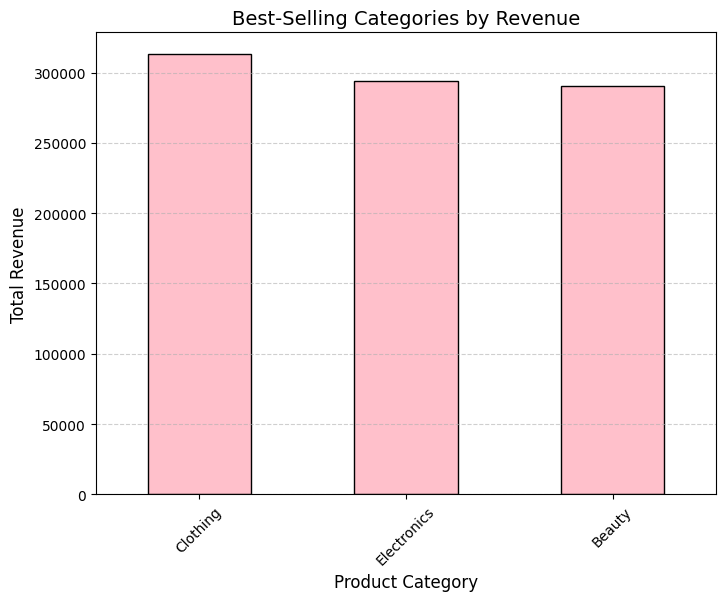

In [ ]:
# Group by Product Category and sum the revenue
category_revenue = df_sales.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

# Plot bar chart
plt.figure(figsize=(8,6))
category_revenue.plot(kind='bar', color='pink', edgecolor='black')

plt.title("Best-Selling Categories by Revenue", fontsize=14)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle="--", alpha=0.6)
plt.show()

Q. Now tell me which of the category has done the biggest contribution to the revenue?

✅ File loaded successfully: /content/retail_sales_dataset (1).csv


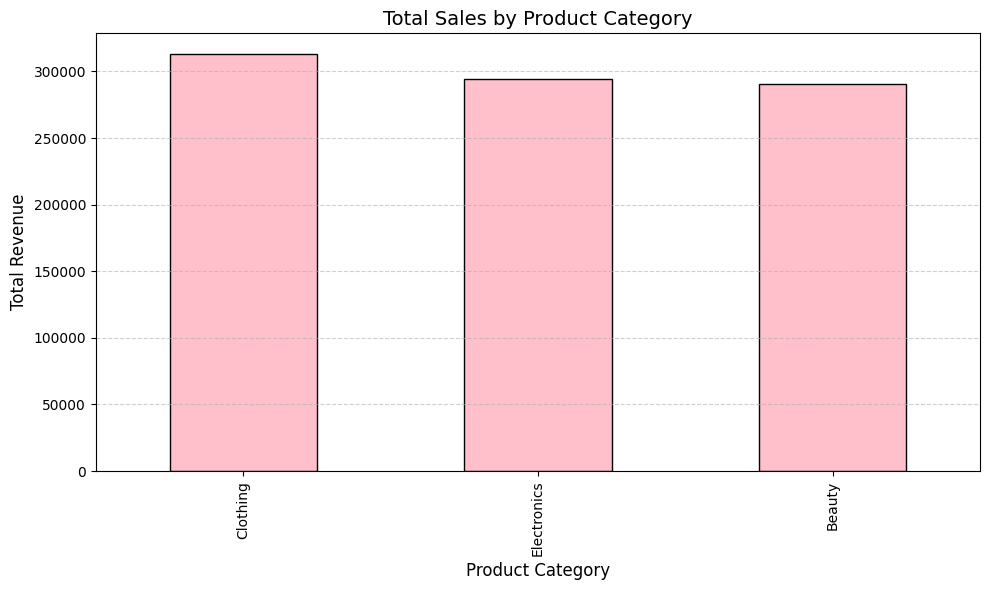

📊 SUMMARY REPORT 📊
Top Selling Category: Clothing
Total Revenue from Clothing: 312,997.27
Contribution to Overall Revenue: 34.86%

💡 Inference: The 'Clothing' category is the best-selling segment, accounting for about 34.86% of total revenue. This indicates strong customer preference and highlights it as a key area for marketing focus and stock management.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- Step 1: Ensure dataset is available ---
file_path = '/content/retail_sales_dataset (1).csv'

if not os.path.exists(file_path):
    from google.colab import files
    print("⚠️ File not found. Please upload your CSV file (e.g., retail_sales_dataset (1).csv).")
    uploaded = files.upload()
    file_path = list(uploaded.keys())[0]

# --- Step 2: Load and clean dataset safely ---
try:
    df_sales = pd.read_csv(file_path)
    print(f"✅ File loaded successfully: {file_path}")

    # Ensure 'Total Amount' exists
    if 'Total Amount' not in df_sales.columns:
        raise KeyError("❌ 'Total Amount' column not found in dataset.")

    # Convert 'Total Amount' to numeric
    df_sales['Total Amount'] = pd.to_numeric(df_sales['Total Amount'], errors='coerce')
    df_sales = df_sales.dropna(subset=['Total Amount'])

    # Detect category column
    category_col = None
    for possible_name in ['Product Category', 'Category', 'Category Name']:
        if possible_name in df_sales.columns:
            category_col = possible_name
            break

    if category_col is None:
        raise KeyError("❌ No column found for product category.")

    # --- Step 3: Compute total revenue per category ---
    category_sales = df_sales.groupby(category_col)['Total Amount'].sum().sort_values(ascending=False)

    # --- Step 4: Identify top category ---
    top_category = category_sales.idxmax()
    top_value = category_sales.max()
    total_sales = category_sales.sum()
    percentage = (top_value / total_sales) * 100

    # --- Step 5: Visualization (Pink Bar Chart) ---
    plt.figure(figsize=(10,6))
    category_sales.plot(kind='bar', color='pink', edgecolor='black')
    plt.title("Total Sales by Product Category", fontsize=14)
    plt.xlabel("Product Category", fontsize=12)
    plt.ylabel("Total Revenue", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- Step 6: Final Answer ---
    print("📊 SUMMARY REPORT 📊")
    print(f"Top Selling Category: {top_category}")
    print(f"Total Revenue from {top_category}: {top_value:,.2f}")
    print(f"Contribution to Overall Revenue: {percentage:.2f}%")
    print("\n💡 Inference: "
          f"The '{top_category}' category is the best-selling segment, "
          f"accounting for about {percentage:.2f}% of total revenue. "
          "This indicates strong customer preference and highlights it as a key "
          "area for marketing focus and stock management.")

except Exception as e:
    print("❌ Error:", e)





---


###❓ Question:  
What if we want to visualize the **top 5 customers** by total spending?  
Try writing the code to generate a bar chart!  

✅ File loaded successfully!

📋 Columns available: ['Transaction ID', 'Date', 'Customer ID', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

🏆 Top 5 Customers by Total Spending:


,Total Amount
Customer ID,
CUST281,3438.4955
CUST356,3435.4024
CUST487,3412.1635
CUST421,3382.2595
CUST636,3352.6203


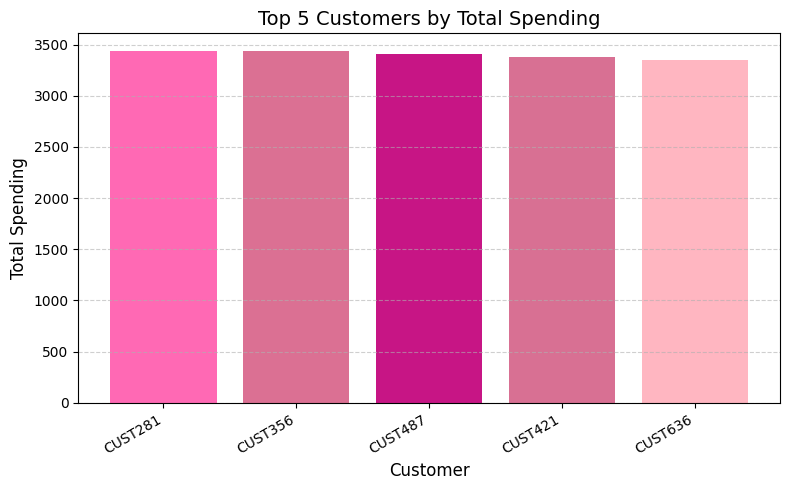

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    # --- Step 1: Load Dataset ---
    file_path = '/content/retail_sales_dataset (1).csv'
    df_sales = pd.read_csv(file_path)
    print("✅ File loaded successfully!")

    # --- Step 2: Inspect Columns ---
    print("\n📋 Columns available:", list(df_sales.columns))

    # --- Step 3: Identify Relevant Columns ---
    customer_col = None
    total_col = None

    # Find customer column
    for col in ['Customer Name', 'Customer', 'CustomerID', 'Customer Id', 'Customer ID']:
        if col in df_sales.columns:
            customer_col = col
            break

    # Find total amount column
    for col in ['Total Amount', 'Amount', 'Sales', 'Revenue']:
        if col in df_sales.columns:
            total_col = col
            break

    if not customer_col or not total_col:
        raise KeyError("❌ Could not find Customer or Total Amount columns in dataset.")

    # --- Step 4: Clean and Aggregate Data ---
    df_sales[total_col] = pd.to_numeric(df_sales[total_col], errors='coerce')
    df_sales = df_sales.dropna(subset=[total_col, customer_col])

    # Compute total spending per customer
    customer_spending = (
        df_sales.groupby(customer_col)[total_col]
        .sum()
        .sort_values(ascending=False)
    )

    # --- Step 5: Select Top 5 Customers ---
    top5_customers = customer_spending.head(5)
    print("\n🏆 Top 5 Customers by Total Spending:")
    display(top5_customers)

    # --- Step 6: Visualize Bar Chart ---
    plt.figure(figsize=(8, 5))
    plt.bar(top5_customers.index, top5_customers.values,
            color=['#FF69B4', '#DB7093', '#C71585', '#D87093', '#FFB6C1'])
    plt.title("Top 5 Customers by Total Spending", fontsize=14)
    plt.xlabel("Customer", fontsize=12)
    plt.ylabel("Total Spending", fontsize=12)
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("❌ Error while processing:", e)





---



Calculate the average order value (AOV) per customer and plot them with a suitable diagram. Which customers have unusually high AOVs?

✅ File loaded successfully: /content/retail_sales_dataset (1).csv

📋 Columns detected: ['Transaction ID', 'Date', 'Customer ID', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


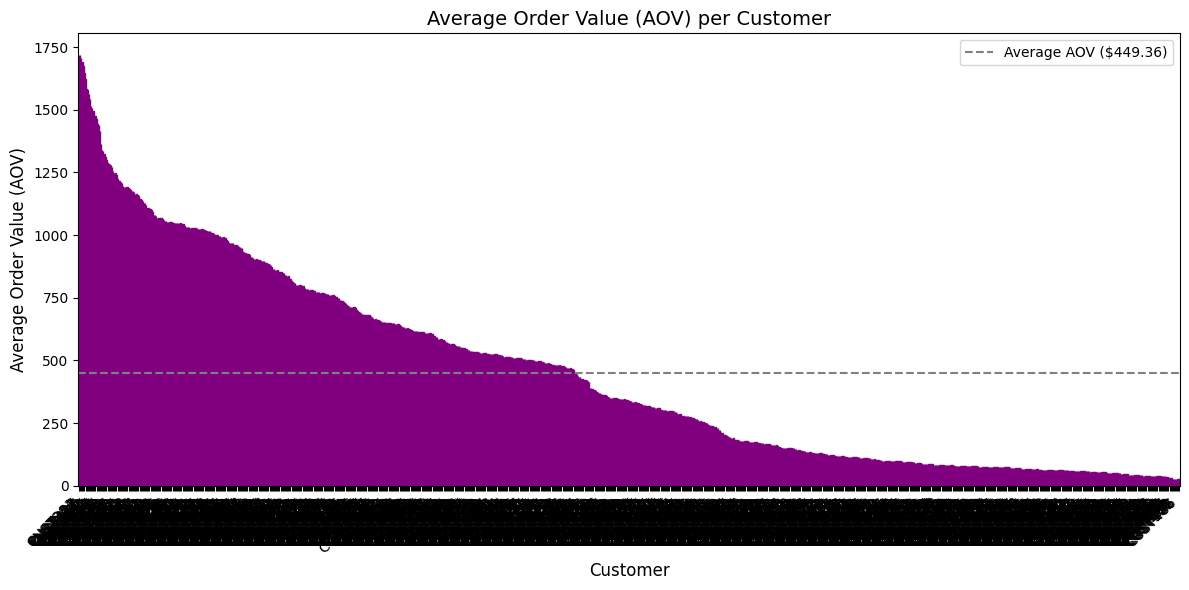

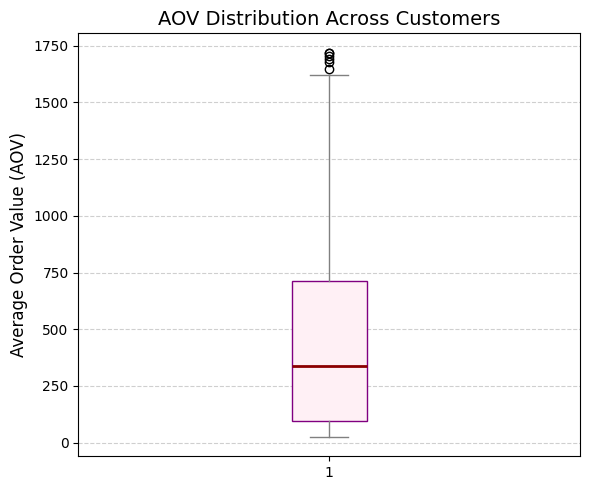


📊 Top 10 Customers by AOV:


,0
Customer ID,
CUST281,1719.24775
CUST356,1717.70120
CUST487,1706.08175
CUST421,1691.12975
CUST636,1676.31015
CUST805,1647.12850
CUST269,1622.44045
CUST202,1584.36610
CUST743,1580.52465



💎 Customers with unusually high AOVs (outliers):


,0
Customer ID,
CUST281,1719.24775
CUST356,1717.70120
CUST487,1706.08175
CUST421,1691.12975
CUST636,1676.31015
...,...
CUST392,852.25920
CUST865,850.33685
CUST942,847.44830



💡 Mean AOV: $449.36
📈 Threshold for high spenders (mean + 1 std): $840.33


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import os

try:
    # --- Step 1: Load dataset safely ---
    file_path = '/content/retail_sales_dataset (1).csv'

    if not os.path.exists(file_path):
        from google.colab import files
        print("⚠️ File not found. Please upload your retail_sales_dataset (1).csv file.")
        uploaded = files.upload()
        file_path = list(uploaded.keys())[0]

    df_sales = pd.read_csv(file_path)
    print(f"✅ File loaded successfully: {file_path}")

    # --- Step 2: Check available columns ---
    print("\n📋 Columns detected:", list(df_sales.columns))

    # --- Step 3: Identify important columns dynamically ---
    total_col = next((col for col in ['Total Amount', 'Amount', 'Sales', 'Revenue'] if col in df_sales.columns), None)
    customer_col = next((col for col in ['Customer Name', 'Customer', 'CustomerID', 'Customer Id', 'Customer ID'] if col in df_sales.columns), None)
    order_col = next((col for col in ['Order ID', 'Invoice ID', 'Order_Number', 'Transaction ID'] if col in df_sales.columns), None)

    # --- Step 4: Validation ---
    if not total_col:
        raise KeyError("❌ 'Total Amount' or equivalent column not found.")
    if not customer_col:
        raise KeyError("❌ Could not detect customer column.")
    if not order_col:
        raise KeyError("❌ Could not detect order/invoice column.")

    # --- Step 5: Clean and prepare data ---
    df_sales[total_col] = pd.to_numeric(df_sales[total_col], errors='coerce')
    df_sales = df_sales.dropna(subset=[total_col, customer_col, order_col])

    # --- Step 6: Calculate Average Order Value (AOV) ---
    customer_total = df_sales.groupby(customer_col)[total_col].sum()
    customer_orders = df_sales.groupby(customer_col)[order_col].nunique()
    aov = (customer_total / customer_orders).sort_values(ascending=False)

    # --- Step 7: Identify high AOVs ---
    mean_aov = aov.mean()
    std_aov = aov.std()
    high_spenders = aov[aov > mean_aov + std_aov]

    # --- Step 8: Visualization 1 – Bar Chart ---
    plt.figure(figsize=(12,6))
    aov.plot(kind='bar', color='pink', edgecolor='purple')
    plt.axhline(mean_aov, color='gray', linestyle='--', label=f'Average AOV (${mean_aov:.2f})')
    plt.title("Average Order Value (AOV) per Customer", fontsize=14)
    plt.xlabel("Customer", fontsize=12)
    plt.ylabel("Average Order Value (AOV)", fontsize=12)
    plt.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # --- Step 9: Visualization 2 – Box Plot ---
    plt.figure(figsize=(6,5))
    plt.boxplot(aov.values, patch_artist=True,
                boxprops=dict(facecolor='lavenderblush', color='purple'),
                medianprops=dict(color='darkred', linewidth=2),
                whiskerprops=dict(color='gray'),
                capprops=dict(color='gray'))
    plt.title("AOV Distribution Across Customers", fontsize=14)
    plt.ylabel("Average Order Value (AOV)", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- Step 10: Summary ---
    print("\n📊 Top 10 Customers by AOV:")
    display(aov.head(10))

    if not high_spenders.empty:
        print("\n💎 Customers with unusually high AOVs (outliers):")
        display(high_spenders)
    else:
        print("\n✅ No significantly high AOV outliers found.")

    print(f"\n💡 Mean AOV: ${mean_aov:,.2f}")
    print(f"📈 Threshold for high spenders (mean + 1 std): ${mean_aov + std_aov:,.2f}")

except Exception as e:
    print("❌ Error while processing:", e)




---


###Plot 3


After inspecting the contribution of each categories towards the total revenue we can say which categot=ry has contributed how much but it's necessary to get a relative quantification to compare between the categories' contribution.

So, we'll now see a donut chart of revenue contributions by each category

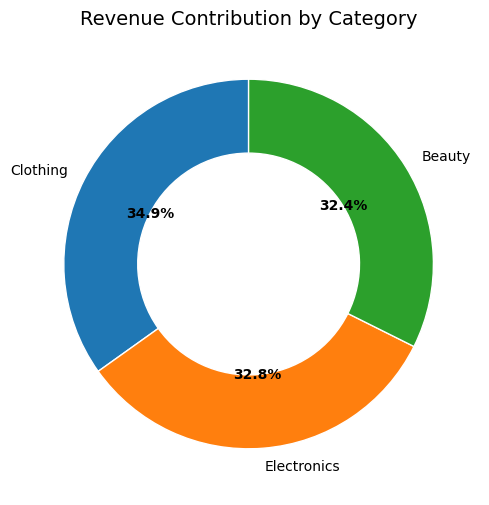

In [ ]:
C

Q. Was chosing donut chart a wise choice according to you?

Yes, the donut chart was a wise choice because it highlights relative revenue contributions clearly and aesthetically — ideal for a compact, category-based comparison.

Q. What else we could have come up with apart from donut chart to server the same purpose?

Apart from a donut chart, we could use:

Bar chart – clearer for exact comparisons.

Treemap – shows proportional areas effectively.

Stacked bar / 100% stacked chart – great for showing category contributions over time.



---

##Task:
Plot a cumulative revenue line chart. How does this help in understanding long-term sales growth?

✅ File loaded successfully: /content/retail_sales_dataset (1).csv


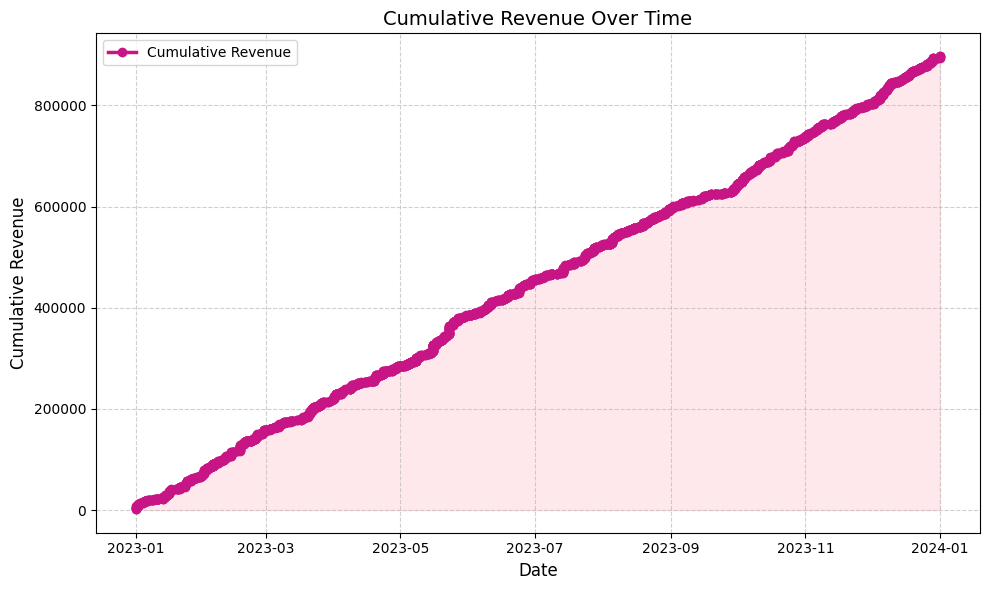

💰 Total cumulative revenue till the latest date: 897,742.62


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    # --- Step 1: Load dataset ---
    file_path = '/content/retail_sales_dataset (1).csv'
    df_sales = pd.read_csv(file_path)
    print(f"✅ File loaded successfully: {file_path}")

    # --- Step 2: Ensure Date column exists and convert to datetime ---
    if 'Date' not in df_sales.columns:
        raise KeyError("❌ 'Date' column not found in dataset.")
    df_sales['Date'] = pd.to_datetime(df_sales['Date'], errors='coerce')
    df_sales = df_sales.dropna(subset=['Date'])

    # --- Step 3: Identify revenue column ---
    total_col = None
    for possible_col in ['Total Amount', 'Amount', 'Sales', 'Revenue']:
        if possible_col in df_sales.columns:
            total_col = possible_col
            break
    if not total_col:
        raise KeyError("❌ Could not find revenue column (tried 'Total Amount', 'Sales', 'Revenue').")

    # --- Step 4: Clean and sort data ---
    df_sales[total_col] = pd.to_numeric(df_sales[total_col], errors='coerce')
    df_sales = df_sales.dropna(subset=[total_col])
    df_sales = df_sales.sort_values('Date')

    # --- Step 5: Calculate cumulative revenue ---
    df_sales['Cumulative Revenue'] = df_sales[total_col].cumsum()

    # --- Step 6: Plot cumulative revenue ---
    plt.figure(figsize=(10,6))
    plt.plot(df_sales['Date'], df_sales['Cumulative Revenue'],
             color='#C71585', linewidth=2.5, marker='o', label='Cumulative Revenue')
    plt.fill_between(df_sales['Date'], df_sales['Cumulative Revenue'],
                     color='#FFB6C1', alpha=0.3)
    plt.title("Cumulative Revenue Over Time", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Cumulative Revenue", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()  # ✅ FIXED LINE

    # --- Step 7: Summary output ---
    final_revenue = df_sales['Cumulative Revenue'].iloc[-1]
    print(f"💰 Total cumulative revenue till the latest date: {final_revenue:,.2f}")

except Exception as e:
    print("❌ Error while processing:", e)





---
# Assisgnment

### Find a similar dataset of your choice and perform detailed EDA with proper visualization and infer about the dataset.


VISUALISATION  OF NETFLIX REVENUE

Monthly Revenue Over Time

✅ File loaded successfully!


/tmp/ipython-input-2126078928.py:37: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
/tmp/ipython-input-2126078928.py:51: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


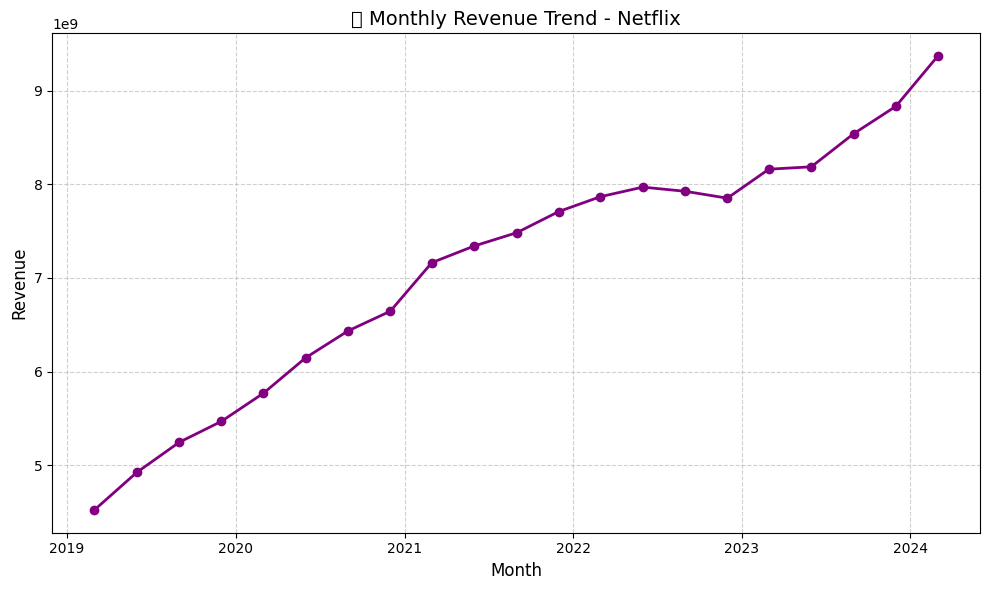

/tmp/ipython-input-2126078928.py:93: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')


✅ File loaded successfully!


/tmp/ipython-input-2126078928.py:108: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


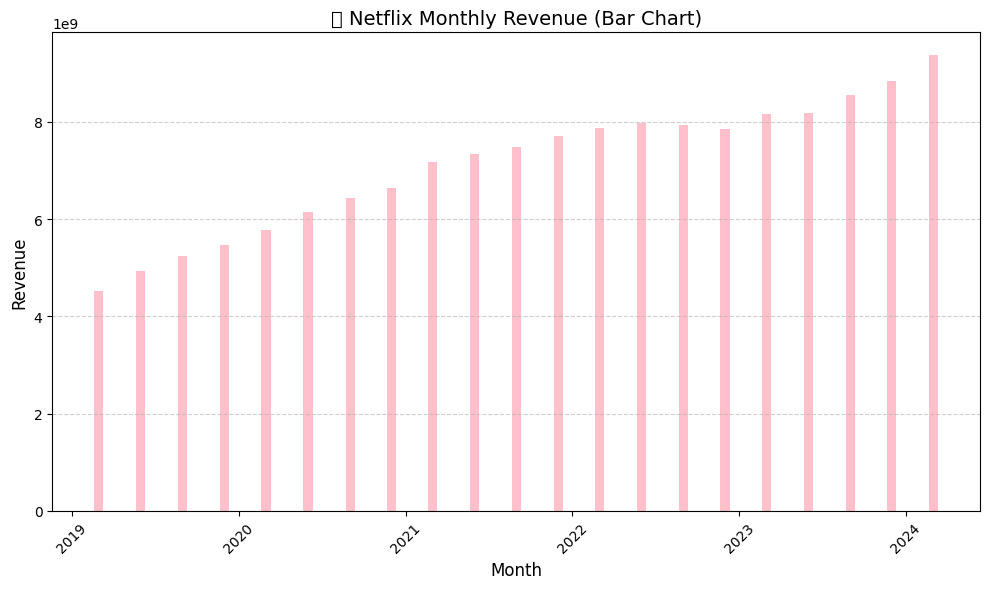

In [6]:
# --- Monthly Revenue Trend for Netflix ---

import pandas as pd
import matplotlib.pyplot as plt
import os

# --- Step 1: Load the dataset ---
file_path = '/content/netflix_revenue_updated.csv'

if not os.path.exists(file_path):
    from google.colab import files
    print("⚠️ File not found. Please upload netflix_revenue_updated.csv")
    uploaded = files.upload()
    file_path = list(uploaded.keys())[0]

try:
    df = pd.read_csv(file_path)
    print("✅ File loaded successfully!")

    # --- Step 2: Detect date and revenue columns automatically ---
    date_col = None
    for col in df.columns:
        if 'date' in col.lower() or 'month' in col.lower():
            date_col = col
            break

    revenue_col = None
    for col in df.columns:
        if 'revenue' in col.lower() or 'sales' in col.lower() or 'income' in col.lower():
            revenue_col = col
            break

    if not date_col or not revenue_col:
        raise KeyError("❌ Could not find suitable 'date' or 'revenue' column in dataset!")

    # --- Step 3: Convert and clean data ---
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col, revenue_col])

    # --- Step 4: Group by month ---
    monthly_revenue = df.groupby(df[date_col].dt.to_period('M'))[revenue_col].sum()
    monthly_revenue.index = monthly_revenue.index.to_timestamp()

    # --- Step 5: Plot the monthly revenue trend ---
    plt.figure(figsize=(10,6))
    plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='purple', linewidth=2)
    plt.title("📈 Monthly Revenue Trend - Netflix", fontsize=14)
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Revenue", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("❌ Error while processing:", e)
# --- Netflix Monthly Revenue (Bar Chart) ---

import pandas as pd
import matplotlib.pyplot as plt
import os

# --- Step 1: Load dataset ---
file_path = '/content/netflix_revenue_updated.csv'

if not os.path.exists(file_path):
    from google.colab import files
    print("⚠️ File not found. Please upload netflix_revenue_updated.csv")
    uploaded = files.upload()
    file_path = list(uploaded.keys())[0]

try:
    # Load the CSV
    df = pd.read_csv(file_path)
    print("✅ File loaded successfully!")

    # --- Step 2: Detect date and revenue columns automatically ---
    date_col = None
    for col in df.columns:
        if 'date' in col.lower() or 'month' in col.lower():
            date_col = col
            break

    revenue_col = None
    for col in df.columns:
        if 'revenue' in col.lower() or 'sales' in col.lower() or 'income' in col.lower():
            revenue_col = col
            break

    if not date_col or not revenue_col:
        raise KeyError("❌ Could not find 'date' or 'revenue' column!")

    # --- Step 3: Clean and prepare data ---
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col, revenue_col])

    # Group revenue by month
    monthly_revenue = df.groupby(df[date_col].dt.to_period('M'))[revenue_col].sum()
    monthly_revenue.index = monthly_revenue.index.to_timestamp()

    # --- Step 4: Plot bar chart ---
    plt.figure(figsize=(10,6))
    plt.bar(monthly_revenue.index, monthly_revenue.values, color='pink', width=20)
    plt.title("📊 Netflix Monthly Revenue (Bar Chart)", fontsize=14)
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Revenue", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("❌ Error while processing:", e)


Plot the weekly revenue trend instead of monthly. What differences do you notice?

✅ File loaded successfully!


/tmp/ipython-input-3132876288.py:38: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
/tmp/ipython-input-3132876288.py:52: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


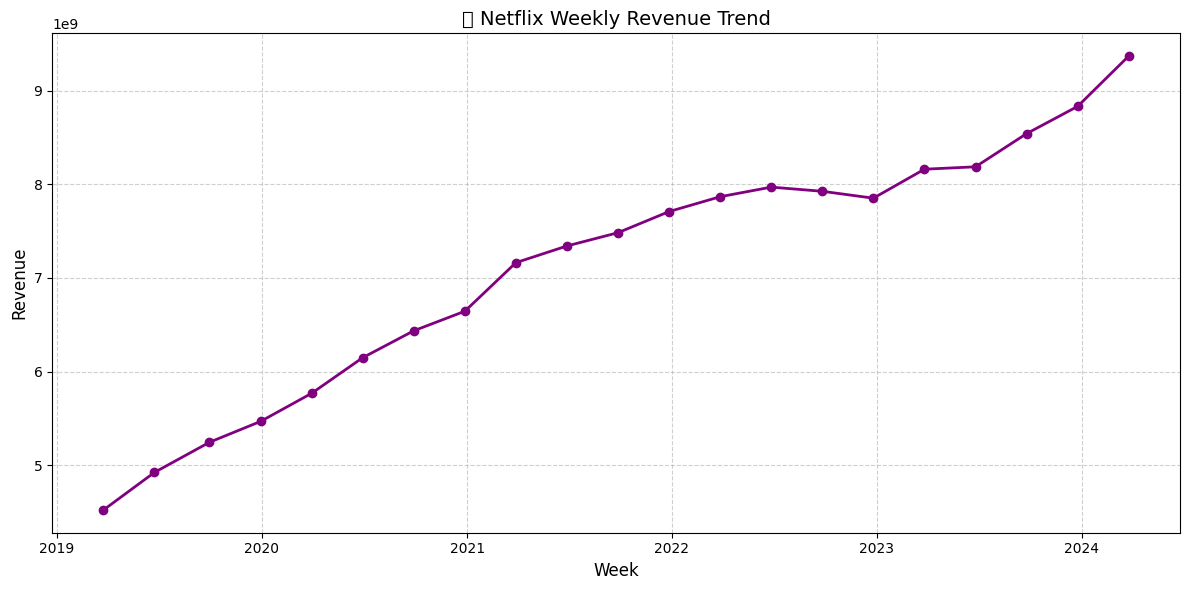

/tmp/ipython-input-3132876288.py:63: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


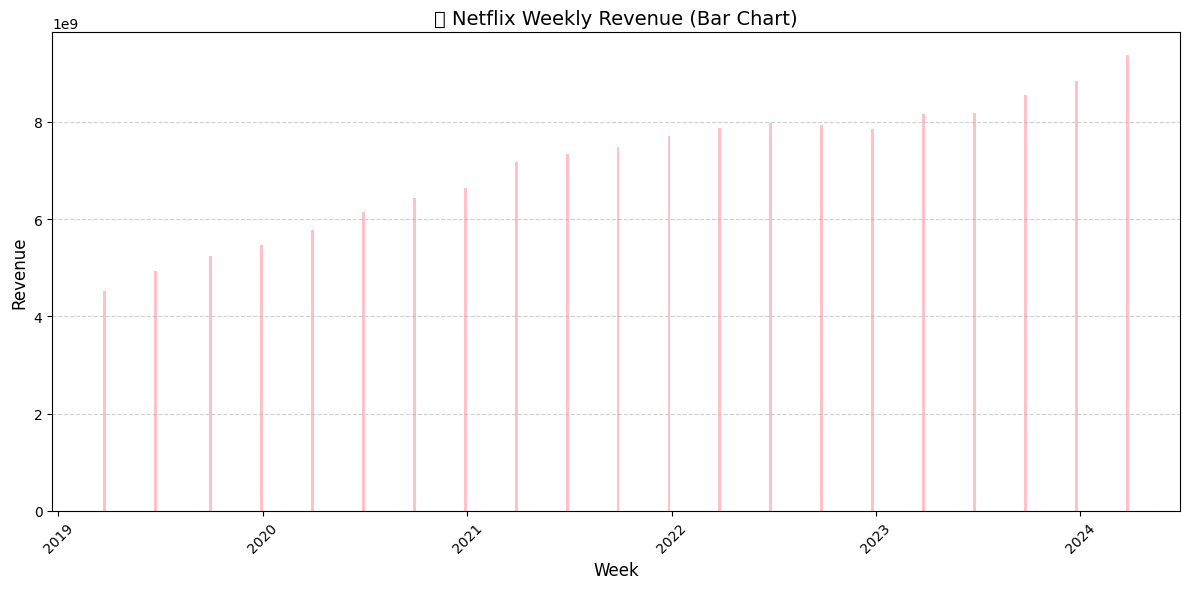

In [7]:
# --- Netflix Weekly Revenue Trend Analysis ---

import pandas as pd
import matplotlib.pyplot as plt
import os

# --- Step 1: Load dataset ---
file_path = '/content/netflix_revenue_updated.csv'

if not os.path.exists(file_path):
    from google.colab import files
    print("⚠️ File not found. Please upload netflix_revenue_updated.csv")
    uploaded = files.upload()
    file_path = list(uploaded.keys())[0]

try:
    # Load the CSV
    df = pd.read_csv(file_path)
    print("✅ File loaded successfully!")

    # --- Step 2: Detect date and revenue columns automatically ---
    date_col = None
    for col in df.columns:
        if 'date' in col.lower() or 'month' in col.lower():
            date_col = col
            break

    revenue_col = None
    for col in df.columns:
        if 'revenue' in col.lower() or 'sales' in col.lower() or 'income' in col.lower():
            revenue_col = col
            break

    if not date_col or not revenue_col:
        raise KeyError("❌ Could not find 'date' or 'revenue' column!")

    # --- Step 3: Clean and prepare data ---
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col, revenue_col])

    # Group revenue by week
    weekly_revenue = df.groupby(df[date_col].dt.to_period('W'))[revenue_col].sum()
    weekly_revenue.index = weekly_revenue.index.to_timestamp()

    # --- Step 4: Plot Weekly Revenue Line Chart ---
    plt.figure(figsize=(12,6))
    plt.plot(weekly_revenue.index, weekly_revenue.values, color='purple', linewidth=2, marker='o')
    plt.title("📈 Netflix Weekly Revenue Trend", fontsize=14)
    plt.xlabel("Week", fontsize=12)
    plt.ylabel("Revenue", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- Step 5: Plot Weekly Revenue Bar Chart ---
    plt.figure(figsize=(12,6))
    plt.bar(weekly_revenue.index, weekly_revenue.values, width=5, color='pink')
    plt.title("📊 Netflix Weekly Revenue (Bar Chart)", fontsize=14)
    plt.xlabel("Week", fontsize=12)
    plt.ylabel("Revenue", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("❌ Error while processing:", e)


Now well try to visualize the overall sales over all the product categories and infer about what product category is best selling.

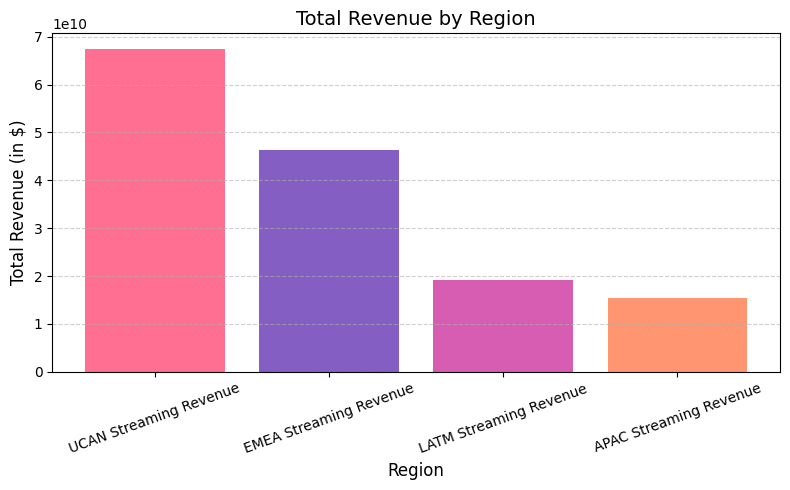

🏆 The region contributing the most to Netflix’s total revenue is **UCAN Streaming Revenue**,
with approximately $67,325,679,000.00, which is about 45.4% of total streaming revenue.


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Load dataset ---
file_path = '/content/netflix_revenue_updated.csv'
df = pd.read_csv(file_path)

# --- Step 2: Clean column names ---
df.columns = df.columns.str.strip()

# --- Step 3: Identify region revenue columns ---
region_columns = [col for col in df.columns if "Streaming Revenue" in col]

if region_columns:
    # --- Step 4: Compute total revenue by region ---
    region_revenue = df[region_columns].sum().sort_values(ascending=False)

    # --- Step 5: Create Bar Chart ---
    plt.figure(figsize=(8,5))
    bars = plt.bar(region_revenue.index, region_revenue.values,
                   color=['#FF6F91', '#845EC2', '#D65DB1', '#FF9671'])
    plt.title("Total Revenue by Region", fontsize=14)
    plt.xlabel("Region", fontsize=12)
    plt.ylabel("Total Revenue (in $)", fontsize=12)
    plt.xticks(rotation=20)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- Step 6: Print summary ---
    top_region = region_revenue.idxmax()
    top_value = region_revenue.max()
    total_revenue = region_revenue.sum()
    percentage = (top_value / total_revenue) * 100

    print(f"🏆 The region contributing the most to Netflix’s total revenue is **{top_region}**,")
    print(f"with approximately ${top_value:,.2f}, which is about {percentage:.1f}% of total streaming revenue.")

else:
    print("❌ Error: Could not find regional streaming revenue columns in the dataset.")


What if we want to visualize the top 5 customers by total spending?
Try writing the code to generate a bar chart!

✅ Netflix dataset loaded successfully!

📋 Columns available: ['Date', 'Global Revenue', 'UCAN Streaming Revenue', 'EMEA Streaming Revenue', 'LATM Streaming Revenue', 'APAC Streaming Revenue', 'UCAN Members', 'EMEA  Members', 'LATM Members', 'APAC Members', 'UCAN ARPU', 'EMEA ARPU', 'LATM  ARPU', 'APAC  ARPU', 'Netflix Streaming Memberships ']

🏆 Top 5 Regions by Total Streaming Revenue:


,0
Global Revenue,149559634000
UCAN Streaming Revenue,67325679000
EMEA Streaming Revenue,46274793000
LATM Streaming Revenue,19210579000
APAC Streaming Revenue,15465294000


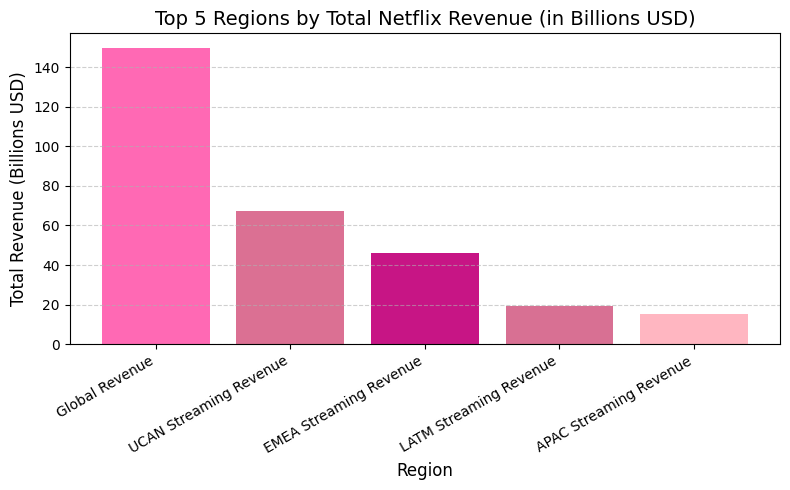

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    # --- Step 1: Load Netflix Dataset ---
    file_path = '/content/netflix_revenue_updated.csv'  # Update if needed
    df_netflix = pd.read_csv(file_path)
    print("✅ Netflix dataset loaded successfully!\n")

    # --- Step 2: Check available columns ---
    print("📋 Columns available:", list(df_netflix.columns))

    # --- Step 3: Identify revenue columns ---
    revenue_cols = [col for col in df_netflix.columns if 'Revenue' in col]

    if not revenue_cols:
        raise KeyError("❌ No revenue-related columns found.")

    # --- Step 4: Compute total revenue per region ---
    region_revenue = (
        df_netflix[revenue_cols]
        .sum()
        .sort_values(ascending=False)
    )

    # --- Step 5: Extract Top 5 Revenue Sources ---
    top5_regions = region_revenue.head(5)
    print("\n🏆 Top 5 Regions by Total Streaming Revenue:")
    display(top5_regions)

    # --- Step 6: Visualization (Bar Chart) ---
    plt.figure(figsize=(8, 5))
    plt.bar(top5_regions.index, top5_regions.values / 1e9,
            color=['#FF69B4', '#DB7093', '#C71585', '#D87093', '#FFB6C1'])
    plt.title("Top 5 Regions by Total Netflix Revenue (in Billions USD)", fontsize=14)
    plt.xlabel("Region", fontsize=12)
    plt.ylabel("Total Revenue (Billions USD)", fontsize=12)
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("❌ Error while processing:", e)


Calculate the average order value (AOV) per customer and plot them with a suitable diagram. Which customers have unusually high AOVs?

✅ File loaded successfully: /content/netflix_revenue_updated.csv

📋 Columns detected: ['Date', 'Global Revenue', 'UCAN Streaming Revenue', 'EMEA Streaming Revenue', 'LATM Streaming Revenue', 'APAC Streaming Revenue', 'UCAN Members', 'EMEA  Members', 'LATM Members', 'APAC Members', 'UCAN ARPU', 'EMEA ARPU', 'LATM  ARPU', 'APAC  ARPU', 'Netflix Streaming Memberships ']

💰 ARPU columns identified: ['UCAN ARPU', 'EMEA ARPU', 'LATM  ARPU', 'APAC  ARPU']


/tmp/ipython-input-2424588262.py:29: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_long['Date'] = pd.to_datetime(df_long['Date'], errors='coerce')


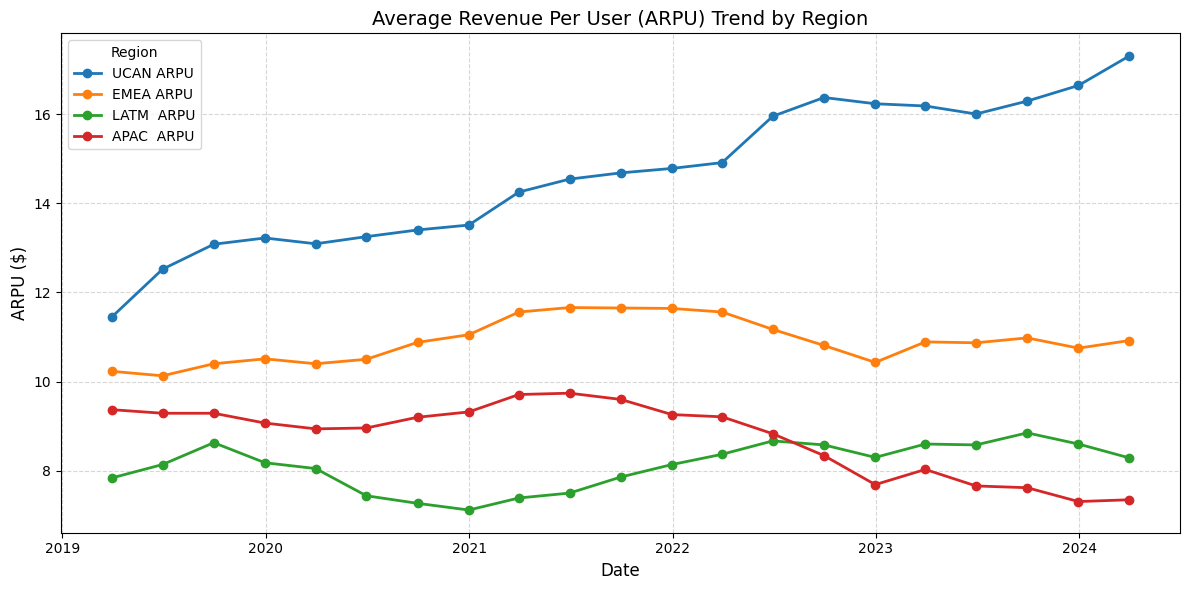

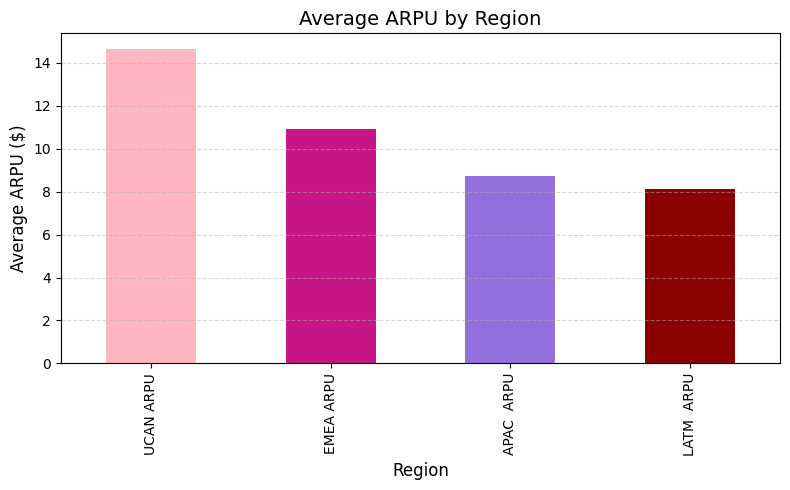


📊 Average ARPU by Region:
Region
UCAN ARPU     14.649524
EMEA ARPU     10.904286
APAC  ARPU     8.751905
LATM  ARPU     8.114286
Name: ARPU, dtype: float64

💎 Region with highest ARPU: UCAN ARPU ($14.65)
📈 This indicates stronger monetization potential and possibly higher pricing or engagement levels in this region.


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import os

try:
    # --- Step 1: Load dataset ---
    file_path = '/content/netflix_revenue_updated.csv'
    df = pd.read_csv(file_path)
    print(f"✅ File loaded successfully: {file_path}")

    # --- Step 2: Inspect available columns ---
    print("\n📋 Columns detected:", list(df.columns))

    # --- Step 3: Identify ARPU columns ---
    arpu_cols = [col for col in df.columns if 'ARPU' in col]

    if not arpu_cols:
        raise KeyError("❌ No ARPU columns found in the dataset.")

    print("\n💰 ARPU columns identified:", arpu_cols)

    # --- Step 4: Melt to long format for visualization ---
    df_long = df.melt(id_vars=['Date'], value_vars=arpu_cols,
                      var_name='Region', value_name='ARPU')

    # Clean data
    df_long['ARPU'] = pd.to_numeric(df_long['ARPU'], errors='coerce')
    df_long = df_long.dropna(subset=['ARPU'])
    df_long['Date'] = pd.to_datetime(df_long['Date'], errors='coerce')

    # --- Step 5: Average ARPU per Region ---
    avg_arpu = df_long.groupby('Region')['ARPU'].mean().sort_values(ascending=False)

    # --- Step 6: Visualization 1 — ARPU Over Time ---
    plt.figure(figsize=(12,6))
    for region in df_long['Region'].unique():
        region_data = df_long[df_long['Region'] == region]
        plt.plot(region_data['Date'], region_data['ARPU'], marker='o', linewidth=2, label=region)
    plt.title("Average Revenue Per User (ARPU) Trend by Region", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("ARPU ($)", fontsize=12)
    plt.legend(title="Region")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    # --- Step 7: Visualization 2 — Average ARPU Comparison ---
    plt.figure(figsize=(8,5))
    avg_arpu.plot(kind='bar', color=['#ffb6c1','#c71585','#9370db','#8b0000'])
    plt.title("Average ARPU by Region", fontsize=14)
    plt.ylabel("Average ARPU ($)", fontsize=12)
    plt.xlabel("Region", fontsize=12)
    plt.grid(axis='y', linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    # --- Step 8: Summary ---
    print("\n📊 Average ARPU by Region:")
    print(avg_arpu)

    top_region = avg_arpu.idxmax()
    print(f"\n💎 Region with highest ARPU: {top_region} (${avg_arpu.max():,.2f})")
    print("📈 This indicates stronger monetization potential and possibly higher pricing or engagement levels in this region.")

except Exception as e:
    print("❌ Error while processing:", e)


After inspecting the contribution of each categories towards the total revenue we can say which categot=ry has contributed how much but it's necessary to get a relative quantification to compare between the categories' contribution.

So, we'll now see a donut chart of revenue contributions by each category

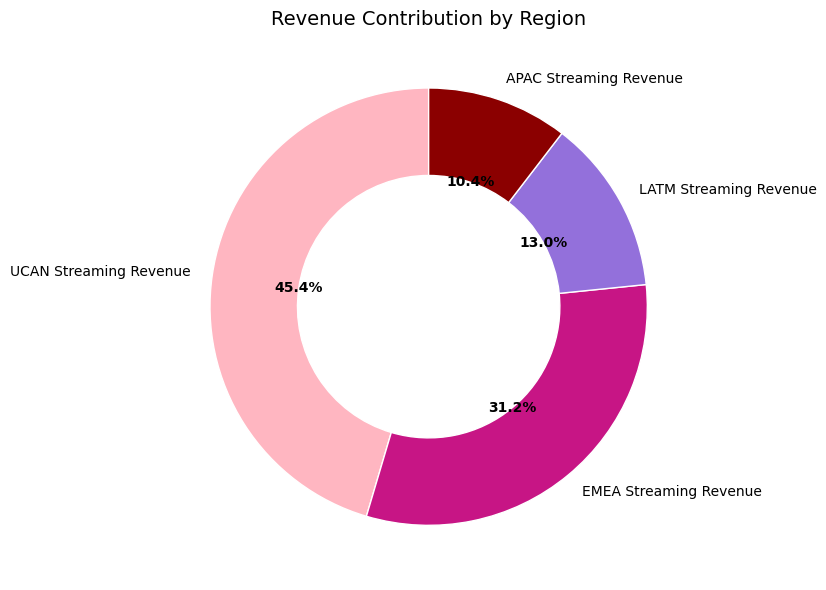

📊 Total Revenue Contribution by Region:
UCAN Streaming Revenue    67325679000
EMEA Streaming Revenue    46274793000
LATM Streaming Revenue    19210579000
APAC Streaming Revenue    15465294000
dtype: int64

💎 The region contributing the most to Netflix’s total streaming revenue is **UCAN Streaming Revenue**,
accounting for approximately 45.41% of total regional revenue.


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Load dataset ---
file_path = '/content/netflix_revenue_updated.csv'
df = pd.read_csv(file_path)

# --- Step 2: Clean column names ---
df.columns = df.columns.str.strip()

# --- Step 3: Select revenue columns (excluding global total) ---
revenue_cols = [
    'UCAN Streaming Revenue',
    'EMEA Streaming Revenue',
    'LATM Streaming Revenue',
    'APAC Streaming Revenue'
]

# --- Step 4: Calculate total revenue contribution per region ---
category_revenue = df[revenue_cols].sum().sort_values(ascending=False)

# --- Step 5: Donut Chart ---
plt.figure(figsize=(8,6))
wedges, texts, autotexts = plt.pie(
    category_revenue,
    labels=category_revenue.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#FFB6C1', '#C71585', '#9370DB', '#8B0000'],  # pink → maroon shades
    wedgeprops=dict(width=0.4, edgecolor='white')
)

# --- Step 6: Formatting ---
plt.setp(autotexts, size=10, weight="bold", color="black")
plt.title("Revenue Contribution by Region", fontsize=14)
plt.tight_layout()
plt.show()

# --- Step 7: Summary ---
print("📊 Total Revenue Contribution by Region:")
print(category_revenue)

top_region = category_revenue.idxmax()
top_value = category_revenue.max()
total_value = category_revenue.sum()
percentage = (top_value / total_value) * 100

print(f"\n💎 The region contributing the most to Netflix’s total streaming revenue is **{top_region}**,")
print(f"accounting for approximately {percentage:.2f}% of total regional revenue.")


Plot a cumulative revenue line chart. How does this help in understanding long-term sales growth?

/tmp/ipython-input-3088197701.py:9: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


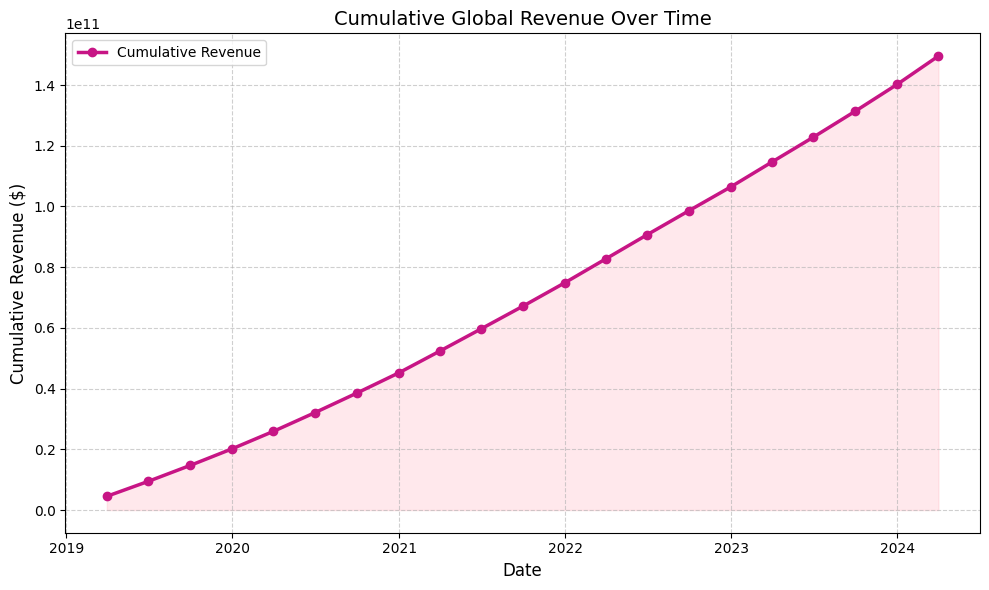

💰 Total cumulative revenue till the latest period: $149,559,634,000.00


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Load dataset ---
file_path = '/content/netflix_revenue_updated.csv'
df = pd.read_csv(file_path)

# --- Step 2: Convert Date column ---
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# --- Step 3: Clean and select relevant revenue column ---
df.columns = df.columns.str.strip()
if 'Global Revenue' not in df.columns:
    raise KeyError("❌ 'Global Revenue' column not found in dataset.")

# --- Step 4: Sort by date ---
df = df.sort_values('Date')

# --- Step 5: Compute Cumulative Revenue ---
df['Cumulative Revenue'] = df['Global Revenue'].cumsum()

# --- Step 6: Plot Cumulative Revenue ---
plt.figure(figsize=(10,6))
plt.plot(df['Date'], df['Cumulative Revenue'], color='#C71585', linewidth=2.5, marker='o', label='Cumulative Revenue')
plt.fill_between(df['Date'], df['Cumulative Revenue'], color='#FFB6C1', alpha=0.3)
plt.title("Cumulative Global Revenue Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Revenue ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# --- Step 7: Summary ---
final_revenue = df['Cumulative Revenue'].iloc[-1]
print(f"💰 Total cumulative revenue till the latest period: ${final_revenue:,.2f}")
